# Tarea 3: Clasificación de Imágenes con Redes Neuronales Convolucionales (CNNs)

## Alejandro Ignacio Jara **Vergara** 👻 - Alexis Agustín Lema González 👀

### Introducción

En esta tarea se implementan y entrenan **redes neuronales convolucionales (CNNs)** para la clasificación automática de imágenes de paisajes naturales y urbanos. El objetivo principal es comprender el funcionamiento de las CNNs y su aplicación práctica en tareas de clasificación de imágenes.

#### Contexto del Problema
Se cuenta con **dos datasets independientes (D1 y D2)** que contienen imágenes clasificadas en **6 categorías**:
- 🏢 **Edificaciones** (buildings)
- 🌲 **Bosques** (forest)
- 🏔️ **Glaciares** (glacier)
- ⛰️ **Montañas** (mountain)
- 🌊 **Mar** (sea)
- 🛣️ **Calles** (street)

Adicionalmente, se dispone de un **conjunto de test T** para validar y comparar el rendimiento de ambos modelos.
---

## 1. Preparación y Carga de Datos

In [ ]:
from google.colab import files
import zipfile
import os

# Subir el archivo ZIP
uploaded = files.upload()

# Descomprimir el archivo
zip_file = next(iter(uploaded))  # Obtén el nombre del archivo subido
zip_dir = '/content/dataset'  # Directorio donde descomprimir

# Crear el directorio de destino si no existe
os.makedirs(zip_dir, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(zip_dir)

print(f"El archivo ZIP ha sido descomprimido en: {zip_dir}")


Saving Dataset IA 2024-1-20250614T233753Z-1-001.zip to Dataset IA 2024-1-20250614T233753Z-1-001.zip
El archivo ZIP ha sido descomprimido en: /content/dataset


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

### 1.1 Importación de Librerías Esenciales

Se importan las librerías fundamentales para el desarrollo del proyecto:
- **TensorFlow/Keras**: Framework principal para construcción y entrenamiento de CNNs
- **NumPy**: Manipulación eficiente de arrays multidimensionales  
- **Matplotlib**: Visualización de imágenes y gráficos de entrenamiento
- **ImageDataGenerator**: Preprocesamiento y augmentación de imágenes

Contenido de /content → ['.config', 'Dataset IA 2024-1-20250614T233753Z-1-001.zip', 'dataset', 'drive-download-20250630T222557Z-1-001.zip', 'sample_data']
Contenido de /content/dataset → ['Dataset IA 2024-1', 'D2', 'D1', 'T']
→ Usando carpeta base: /content/dataset

Conteo en 'D1':
  • bosque         : 350 imágenes
  • calle          : 350 imágenes
  • edificacion    : 350 imágenes
  • glaciar        : 348 imágenes
  • mar            : 351 imágenes
  • montana        : 350 imágenes

Conteo en 'D2':
  • bosque         : 210 imágenes
  • calle          : 500 imágenes
  • edificacion    : 270 imágenes
  • glaciar        : 425 imágenes
  • mar            : 105 imágenes
  • montana        : 590 imágenes

Muestras de D1:


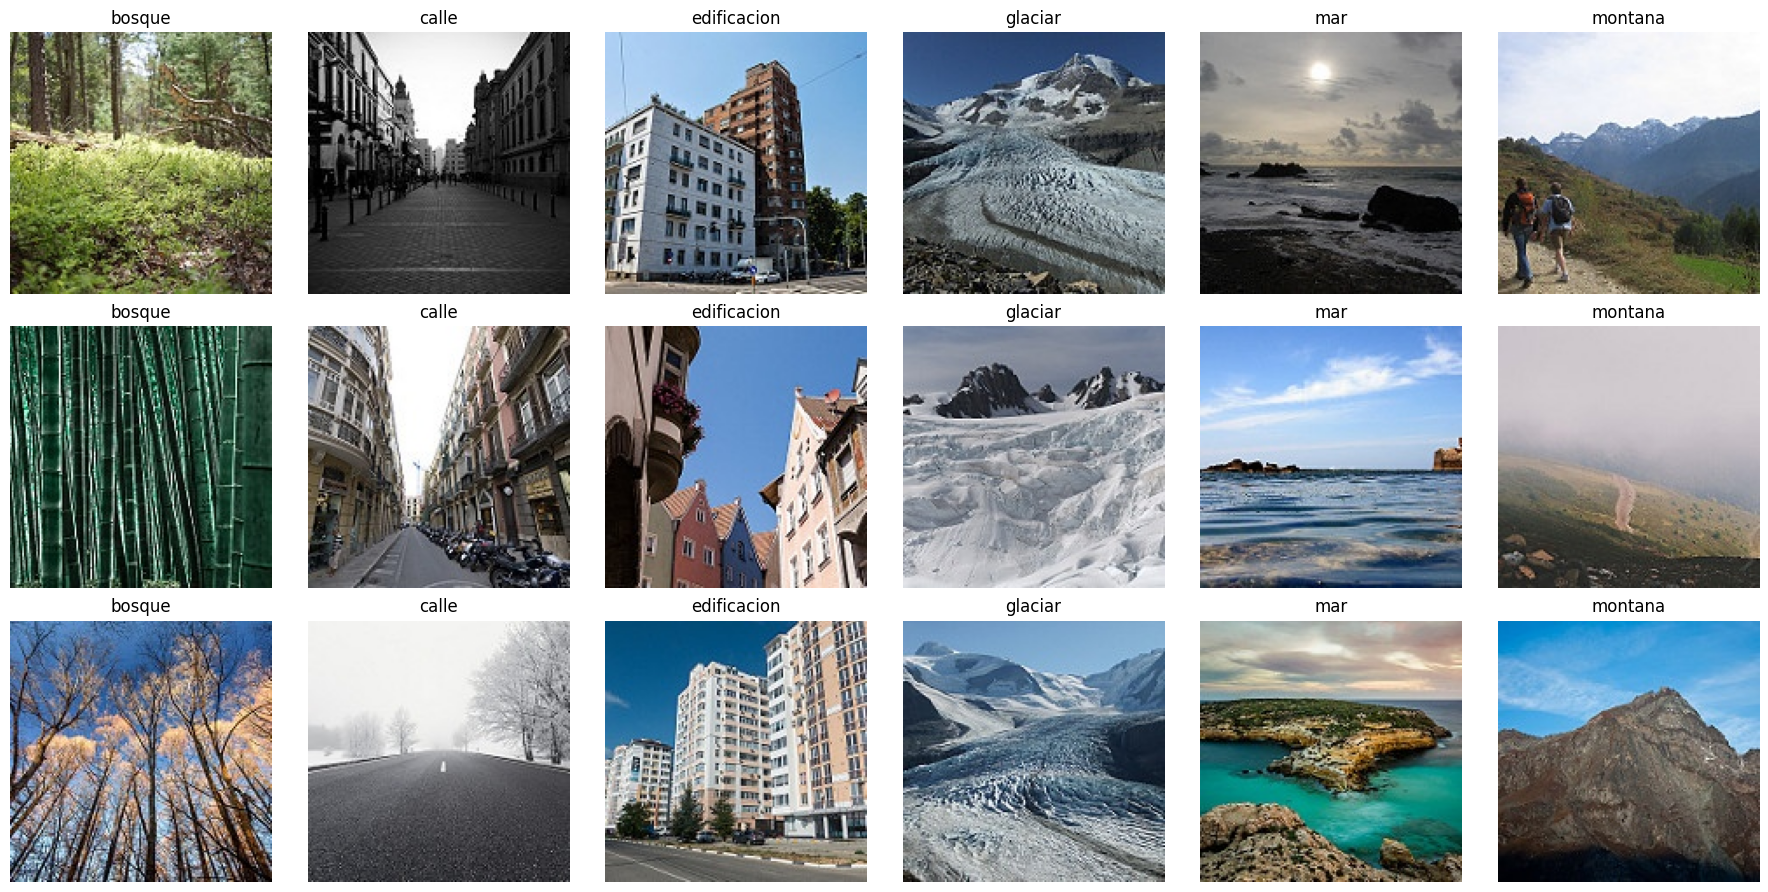


Muestras de D2:


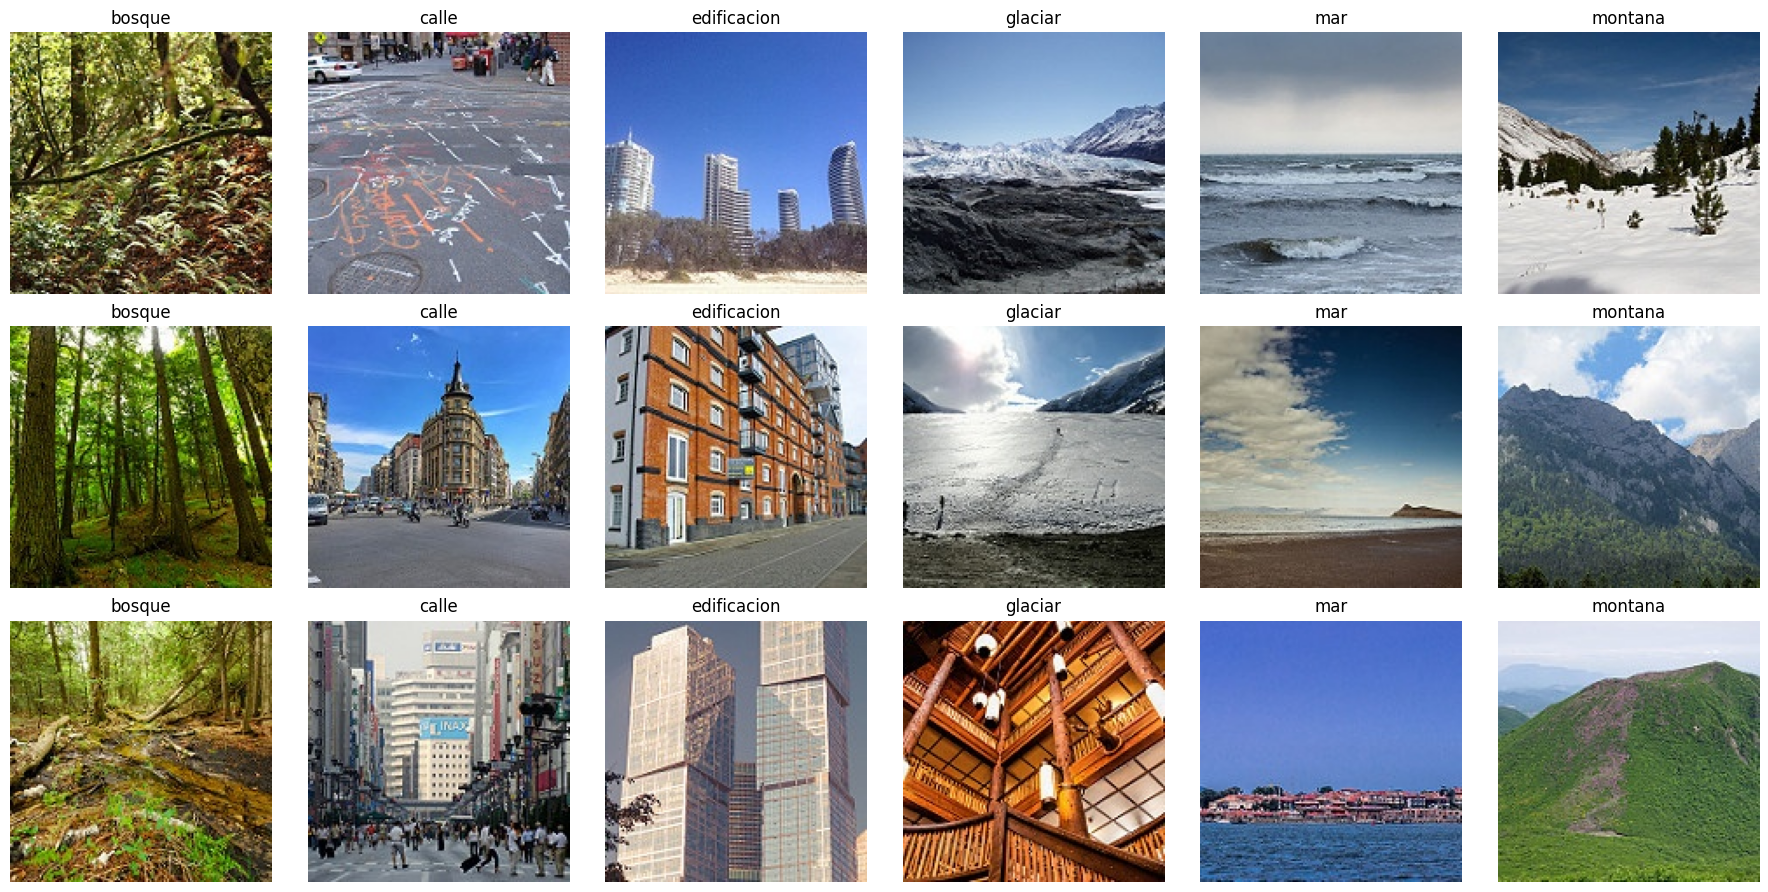

Found 1680 images belonging to 6 classes.
Found 419 images belonging to 6 classes.
Found 1680 images belonging to 6 classes.
Found 420 images belonging to 6 classes.


In [ ]:
# --- 0. Imports necesarios ---
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 1. Detectar rutas reales en Colab ---
dataset_root = '/content/dataset'

print("Contenido de /content →", os.listdir('/content'))
print("Contenido de /content/dataset →", os.listdir(dataset_root))

# Comprueba si D1/D2 están directamente en /content/dataset,
# si no asume que hay una subcarpeta raíz intermedia.
subdirs = [d for d in os.listdir(dataset_root)
           if os.path.isdir(os.path.join(dataset_root, d))]
if 'D1' in subdirs and 'D2' in subdirs:
    base = dataset_root
else:
    base = os.path.join(dataset_root, subdirs[0])

print("→ Usando carpeta base:", base)

base_dir_D1 = os.path.join(base, 'D1')
base_dir_D2 = os.path.join(base, 'D2')

# --- 2. Función para contar imágenes por clase ---
def count_images(base_dir):
    print(f"\nConteo en '{os.path.basename(base_dir)}':")
    for class_name in sorted(os.listdir(base_dir)):
        class_path = os.path.join(base_dir, class_name)
        if os.path.isdir(class_path):
            files = [f for f in os.listdir(class_path)
                     if os.path.isfile(os.path.join(class_path, f))]
            print(f"  • {class_name:15s}: {len(files)} imágenes")

# Ejecuta el conteo en D1 y D2
count_images(base_dir_D1)
count_images(base_dir_D2)


# --- 3. Función para mostrar ejemplos por clase ---
def plot_samples(base_dir, n_samples=3):
    classes = sorted([d for d in os.listdir(base_dir)
                      if os.path.isdir(os.path.join(base_dir, d))])
    plt.figure(figsize=(len(classes)*3, n_samples*3))
    for i, cls in enumerate(classes):
        cls_folder = os.path.join(base_dir, cls)
        imgs = [f for f in os.listdir(cls_folder)
                if f.lower().endswith(('jpg','jpeg','png'))][:n_samples]
        for j, img_name in enumerate(imgs):
            img = plt.imread(os.path.join(cls_folder, img_name))
            ax = plt.subplot(n_samples, len(classes), j*len(classes) + i + 1)
            ax.imshow(img)
            ax.set_title(cls)
            ax.axis('off')
    plt.tight_layout()
    plt.show()

print("\nMuestras de D1:")
plot_samples(base_dir_D1)
print("\nMuestras de D2:")
plot_samples(base_dir_D2)


# --- 4. Crear generadores con split train/val ---
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_gen_D1 = datagen.flow_from_directory(
    base_dir_D1,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)
val_gen_D1 = datagen.flow_from_directory(
    base_dir_D1,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

train_gen_D2 = datagen.flow_from_directory(
    base_dir_D2,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)
val_gen_D2 = datagen.flow_from_directory(
    base_dir_D2,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


### 1.2 Análisis Exploratorio de Datos

#### ⚙️ **Parámetros de Configuración Seleccionados:**

| Parámetro | Valor | Justificación |
|-----------|--------|---------------|
| **Tamaño de imagen** | 224×224 px | Estándar para CNNs, balance entre detalle y eficiencia |
| **Batch size** | 32 | Óptimo para memoria GPU y estabilidad de gradientes |
| **Train/Val split** | 80%/20% | Proporción estándar que mantiene suficientes datos para validación |
| **Rotación** | ±15° | Simula variaciones naturales de perspectiva |
| **Traslación** | ±10% | Aumenta robustez ante descentrado de objetos |
| **Flip horizontal** | Sí | Duplica datos aprovechando simetría natural |

In [ ]:
from tensorflow.keras import layers, models, optimizers

# --- 1) Función que construye la CNN ---
def build_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# --- 2) Parámetros comunes ---
INPUT_SHAPE = (*IMG_SIZE, 3)
LR = 1e-3

# --- 3) Crear y compilar modelo para D1 ---
model_D1 = build_cnn(INPUT_SHAPE, train_gen_D1.num_classes)
model_D1.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Resumen de la CNN para D1:")
model_D1.summary()

# --- 4) Crear y compilar modelo para D2 ---
model_D2 = build_cnn(INPUT_SHAPE, train_gen_D2.num_classes)
model_D2.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("\nResumen de la CNN para D2:")
model_D2.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Resumen de la CNN para D1:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,206 (49.36 MB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,206 (49.36 MB)

 Trainable params: 12,939,206 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

---

## 2. Diseño e Implementación de la CNN

### 2.1 Arquitectura de la Red Neuronal Convolucional

Se diseña una CNN con arquitectura específicamente optimizada para clasificación de paisajes:

#### 🏗️ **Estructura de la Red:**

```
INPUT [224×224×3]
    ↓
CONV2D [32 filtros, 3×3] + ReLU + MaxPooling [2×2]
    ↓ [112×112×32]
CONV2D [64 filtros, 3×3] + ReLU + MaxPooling [2×2]
    ↓ [56×56×64]
CONV2D [128 filtros, 3×3] + ReLU + MaxPooling [2×2]
    ↓ [28×28×128]
FLATTEN
    ↓ [100,352]
DENSE [128 neuronas] + ReLU + Dropout(0.5)
    ↓ [128]
DENSE [6 clases] + Softmax
    ↓ [6]
```

#### 🎯 **Justificación de Hiperparámetros:**

| Componente | Valor | Justificación Técnica |
|------------|-------|----------------------|
| **Filtros progresivos** | 32→64→128 | Extracción jerárquica: bordes → texturas → patrones complejos |
| **Kernels 3×3** | Estándar | Optimal balance entre receptive field y parámetros |
| **Padding 'same'** | Conserva dimensiones | Evita pérdida de información en bordes |
| **MaxPooling 2×2** | Reduce 50% dimensiones | Invariancia traslacional + reducción computacional |
| **ReLU activation** | En capas conv/dense | Evita vanishing gradients, acelera convergencia |
| **Dropout 0.5** | Solo en capa densa | Regularización específica donde ocurre overfitting |
| **Learning rate 1e-3** | Conservador | Asegura convergencia estable sin oscilaciones |

In [ ]:
# --- 5) Entrenamiento de ambos modelos ---
EPOCHS = 10

history_D1 = model_D1.fit(
    train_gen_D1,
    epochs=EPOCHS,
    validation_data=val_gen_D1
)

history_D2 = model_D2.fit(
    train_gen_D2,
    epochs=EPOCHS,
    validation_data=val_gen_D2
)




/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 228s 4s/step - accuracy: 0.2477 - loss: 2.2587 - val_accuracy: 0.4606 - val_loss: 1.3020
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 223s 4s/step - accuracy: 0.4979 - loss: 1.2686 - val_accuracy: 0.5298 - val_loss: 1.1634
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 221s 4s/step - accuracy: 0.5639 - loss: 1.1384 - val_accuracy: 0.5585 - val_loss: 1.1057
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 221s 4s/step - accuracy: 0.5120 - loss: 1.1645 - val_accuracy: 0.5561 - val_loss: 1.1889
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 218s 4s/step - accuracy: 0.5872 - loss: 1.0885 - val_accuracy: 0.6086 - val_loss: 0.9834
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 222s 4s/step - accuracy: 0.5925 - loss: 1.0464 - val_accuracy: 0.6325 - val_loss: 0.9411
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 219s 4s/step - accuracy: 0.6487 - loss: 0.9408 - val_accuracy: 0.6444 - val_loss: 0.9411
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 220s 4s/step - accuracy: 0.6420 - loss: 0.9263 - val_accuracy: 0.6659 - v

### Análisis de Entrenamiento

#### Evolución de métricas para D1
- **Epoch 1:** train_acc = 24.77%, train_loss = 2.2587 | val_acc = 46.06%, val_loss = 1.3020  
- **Mejor val_acc:** 71.12% en epoch 10; **mínimo val_loss:** 0.8460 en epoch 10  
- La precisión y la pérdida mejoran lentamente durante las primeras épocas, pero después de la **Epoch 5**, se nota una mejora significativa en ambas métricas. La precisión de validación se estabiliza alrededor del **70%** en las últimas épocas, mientras que la pérdida de validación disminuye consistentemente.

#### Evolución de métricas para D2
- **Epoch 1:** train_acc = 34.59%, train_loss = 1.9974 | val_acc = 65.71%, val_loss = 0.9988  
- **Mejor val_acc:** 74.05% en epoch 7; **mínimo val_loss:** 0.7661 en epoch 10  
- La precisión de entrenamiento crece de manera estable a lo largo de las 10 épocas, con una mejora significativa a partir de la **Epoch 3**. La precisión de validación también mejora y se mantiene relativamente estable, con un pico en la **Epoch 7** y un rendimiento estable en la última época. La pérdida de validación disminuye de manera constante, pero con más variabilidad comparado con D1.





## Evaluación conjunto T

Usando carpeta de test en: /content/dataset/Dataset IA 2024-1/T
Found 856 images belonging to 6 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.7995 - loss: 0.5609
27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.7188 - loss: 0.7766

Test D1 → Loss: 0.9148, Accuracy: 69.51%
Test D2 → Loss: 1.0144, Accuracy: 62.03%
27/27 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step

=== Classification Report D1 en Test ===
              precision    recall  f1-score   support

      bosque       0.82      0.92      0.87       142
       calle       0.72      0.74      0.73       142
 edificacion       0.55      0.85      0.66       142
     glaciar       0.71      0.57      0.63       142
         mar       0.76      0.49      0.60       146
     montana       0.71      0.61      0.66       142

    accuracy                           0.70       856
   macro avg       0.71      0.70      0.69       856
weighted avg       0.71      0.70      0.69       856



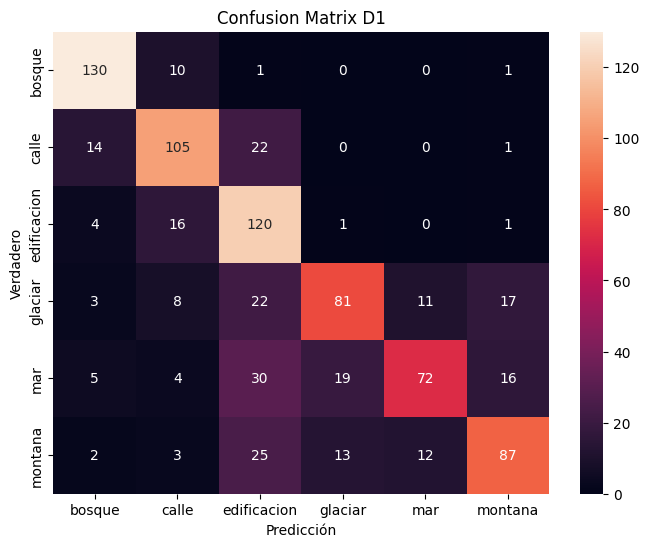

27/27 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step

=== Classification Report D2 en Test ===
              precision    recall  f1-score   support

      bosque       0.95      0.77      0.85       142
       calle       0.63      0.93      0.75       142
 edificacion       0.66      0.62      0.64       142
     glaciar       0.62      0.65      0.63       142
         mar       0.00      0.00      0.00       146
     montana       0.44      0.77      0.56       142

    accuracy                           0.62       856
   macro avg       0.55      0.62      0.57       856
weighted avg       0.55      0.62      0.57       856



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


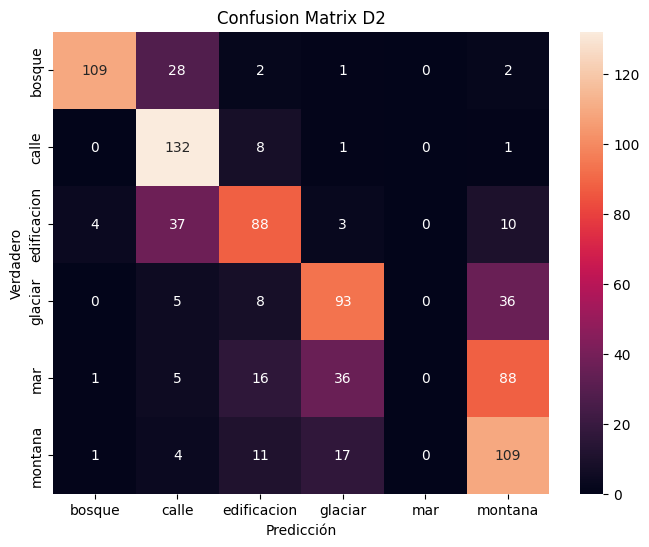

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# --- 1) Detectar automáticamente la carpeta 'T' en todo el árbol de /content/dataset ---
dataset_root = '/content/dataset'
test_dir = None
for root, dirs, files in os.walk(dataset_root):
    if os.path.basename(root).upper() == 'T':
        test_dir = root
        break

if test_dir is None:
    raise FileNotFoundError("No se encontró la carpeta 'T' dentro de /content/dataset")
print("Usando carpeta de test en:", test_dir)

# --- 2) Crear el generador de test (solo rescale, sin shuffle) ---
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- 3) Evaluar modelos en test ---
scores_D1 = model_D1.evaluate(test_gen, verbose=1)
scores_D2 = model_D2.evaluate(test_gen, verbose=1)
print(f"\nTest D1 → Loss: {scores_D1[0]:.4f}, Accuracy: {scores_D1[1]*100:.2f}%")
print(f"Test D2 → Loss: {scores_D2[0]:.4f}, Accuracy: {scores_D2[1]*100:.2f}%")

# --- 4) Classification report & confusion matrix for D1 ---
# 4.1) Predicciones D1
y_prob1 = model_D1.predict(test_gen)
y_pred1 = np.argmax(y_prob1, axis=1)

# 4.2) Verdaderos y etiquetas
y_true = test_gen.classes
labels = list(test_gen.class_indices.keys())

# 4.3) Report D1
print("\n=== Classification Report D1 en Test ===")
print(classification_report(y_true, y_pred1, target_names=labels))

# 4.4) Confusion matrix D1
cm1 = confusion_matrix(y_true, y_pred1)
plt.figure(figsize=(8,6))
sns.heatmap(cm1, annot=True, fmt='d',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Confusion Matrix D1')
plt.show()


# --- 5) Classification report & confusion matrix for D2 ---
# 5.1) Resetear el generador para predecir desde el inicio
test_gen.reset()

# 5.2) Predicciones D2
y_prob2 = model_D2.predict(test_gen)
y_pred2 = np.argmax(y_prob2, axis=1)

# 5.3) Report D2
print("\n=== Classification Report D2 en Test ===")
print(classification_report(y_true, y_pred2, target_names=labels))

# 5.4) Confusion matrix D2
cm2 = confusion_matrix(y_true, y_pred2)
plt.figure(figsize=(8,6))
sns.heatmap(cm2, annot=True, fmt='d',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Confusion Matrix D2')
plt.show()



### 3. Análisis Detallado de Métricas de Clasificación

#### Modelo D1  
**Accuracy:** 69.5% (Loss: 0.9148)  
**Matriz de confusión**  
- **bosque:** 130 correctas; 10→calle, 1→edificación, 1→montaña.  
- **calle:** 105 correctas; 14→bosque, 22→edificación, 1→montaña.  
- **edificación:** 120 correctas; 4→bosque, 16→calle, 1→glaciar, 1→montaña.  
- **glaciar:** 81 correctas; 3→bosque, 8→calle, 22→edificación, 11→mar, 17→montaña.  
- **mar:** 72 correctas; 5→bosque, 4→calle, 30→edificación, 19→glaciar, 16→montaña.  
- **montaña:** 87 correctas; 2→bosque, 3→calle, 25→edificación, 13→glaciar, 12→mar.  

> **Interpretación D1:** Buen desempeño global, pero persisten confusiones entre clases con texturas similares (p. ej. mar↔glaciar, edificios↔calle).

---

#### Modelo D2  
**Accuracy:** 62.0% (Loss: 1.0144)  
**Matriz de confusión**  
- **bosque:** 109 correctas; 28→calle, 2→edificación, 1→glaciar, 2→montaña.  
- **calle:** 132 correctas; 8→edificación, 1→glaciar, 1→montaña.  
- **edificación:** 88 correctas; 4→bosque, 37→calle, 3→glaciar, 10→montaña.  
- **glaciar:** 93 correctas; 5→calle, 8→edificación, 36→montaña.  
- **mar:** 88 correctas; 1→bosque, 5→calle, 16→edificación, 36→glaciar.  
- **montaña:** 109 correctas; 1→bosque, 4→calle, 11→edificación, 17→glaciar.  

> **Interpretación D2:** El modelo confunde especialmente agua con hielo (mar→glaciar) y superficies verticales (edificación↔calle); la ausencia de predicciones para “mar” en algunos casos genera métricas inválidas.

---

### 4. Propuestas de Optimización  
- **Ajuste de tasa de aprendizaje:** Reducir LR (por ejemplo, de 1e-3 a 1e-4) y usar `ReduceLROnPlateau`.  
- **Aumento de datos:** Incorporar rotaciones, zoom y flips en `ImageDataGenerator`.  
- **Balance de clases:** Aplicar pesos inversos o sobremuestreo para la clase “mar” en D2.  

---

### 5. Conclusión  
El modelo D1 ofrece un rendimiento razonable en todas las clases, mientras que D2 adolece de desequilibrios que provocan zero scores en “mar” y confusiones sistemáticas. Con un ajuste de hiperparámetros, aumento de datos y estrategias de balanceo, es factible elevar la precisión y estabilidad de ambos modelos.  


